# Xử lý file JSON



## Import & Config




In [1]:
import os
import json
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt

# ===== PATH =====
DATASET_PATH = "/kaggle/input/datasets/sonlest/bom-dataset/BOM-Dataset"
ANNOTATION_PATH = "/kaggle/input/datasets/sonlest/bom-dataset/instances_default.json"
OUTPUT_JSON = "/kaggle/working/cleaned_instances.json"

# ===== CONFIG =====
MIN_IMAGE_SIZE = 100

## DATA PROCESSING FUNCTIONS


In [2]:
def load_coco_json(path):
    with open(path, 'r') as f:
        return json.load(f)


def is_valid_bbox(bbox, img_w, img_h):
    x, y, w, h = bbox
    
    if w <= 0 or h <= 0:
        return False
    if x < 0 or y < 0:
        return False
    if x + w > img_w:
        return False
    if y + h > img_h:
        return False
    
    return True


def fix_bbox(bbox, img_w, img_h):
    x, y, w, h = bbox
    
    x = max(0, x)
    y = max(0, y)
    
    w = min(w, img_w - x)
    h = min(h, img_h - y)
    
    return [x, y, w, h]


def clean_dataset(data, image_dir):
    image_dict = {img['id']: img for img in data['images']}
    
    valid_images = []
    valid_image_ids = set()
    
    # ===== FILTER IMAGE =====
    for img in data['images']:
        path = os.path.join(image_dir, img['file_name'])
        
        if not os.path.exists(path):
            continue
        
        if img['width'] < MIN_IMAGE_SIZE or img['height'] < MIN_IMAGE_SIZE:
            continue
        
        valid_images.append(img)
        valid_image_ids.add(img['id'])
    
    # ===== CLEAN ANNOTATIONS =====
    cleaned_annotations = []
    
    stats = {
        "removed_images": len(data['images']) - len(valid_images),
        "invalid_bbox": 0,
        "fixed_bbox": 0
    }
    
    for ann in tqdm(data['annotations']):
        if ann['image_id'] not in valid_image_ids:
            continue
        
        img = image_dict[ann['image_id']]
        bbox = ann['bbox']
        
        if not is_valid_bbox(bbox, img['width'], img['height']):
            new_bbox = fix_bbox(bbox, img['width'], img['height'])
            
            if new_bbox[2] <= 0 or new_bbox[3] <= 0:
                stats["invalid_bbox"] += 1
                continue
            
            ann['bbox'] = new_bbox
            stats["fixed_bbox"] += 1
        
        cleaned_annotations.append(ann)
    
    data['images'] = valid_images
    data['annotations'] = cleaned_annotations
    
    return data, stats


def save_json(data, path):
    with open(path, 'w') as f:
        json.dump(data, f)

## ANALYSIS + VISUALIZATION

In [3]:
def analyze_and_visualize(data):
    category_map = {cat['id']: cat['name'] for cat in data['categories']}
    
    category_count = defaultdict(int)
    bbox_areas = []
    obj_per_img = defaultdict(int)
    
    # ===== ANALYSIS =====
    for ann in data['annotations']:
        category_count[ann['category_id']] += 1
        
        _, _, w, h = ann['bbox']
        bbox_areas.append(w * h)
        
        obj_per_img[ann['image_id']] += 1
    
    # ===== CATEGORY PLOT =====
    labels = [category_map[k] for k in category_count.keys()]
    counts = list(category_count.values())
    
    plt.figure()
    plt.bar(labels, counts)
    plt.title("Category Distribution")
    plt.xticks(rotation=30)
    plt.show()
    
    # ===== BBOX AREA =====
    plt.figure()
    plt.hist(bbox_areas, bins=30)
    plt.title("BBox Area Distribution")
    plt.show()
    
    # ===== OBJECT PER IMAGE =====
    plt.figure()
    plt.hist(list(obj_per_img.values()), bins=20)
    plt.title("Objects per Image")
    plt.show()
    
    # ===== IMBALANCE =====
    max_count = max(counts)
    min_count = min(counts)
    ratio = max_count / min_count if min_count > 0 else 0
    
    print("\n📊 IMBALANCE REPORT:")
    for i, c in category_count.items():
        print(f"{category_map[i]}: {c}")
    
    print(f"\nMax: {max_count}")
    print(f"Min: {min_count}")
    print(f"Imbalance ratio: {ratio:.2f}")

## MAIN PIPELINE


🚀 Loading dataset...

🧹 Cleaning dataset...


100%|██████████| 203/203 [00:00<00:00, 646011.92it/s]


📊 CLEANING STATS:
removed_images: 1
invalid_bbox: 0
fixed_bbox: 0
Images: 57
Annotations: 201

📊 Running EDA...


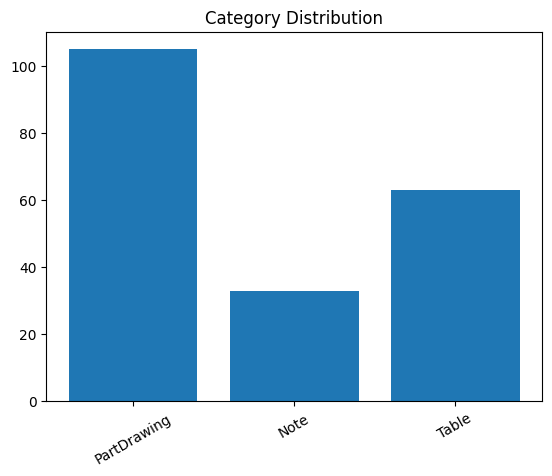

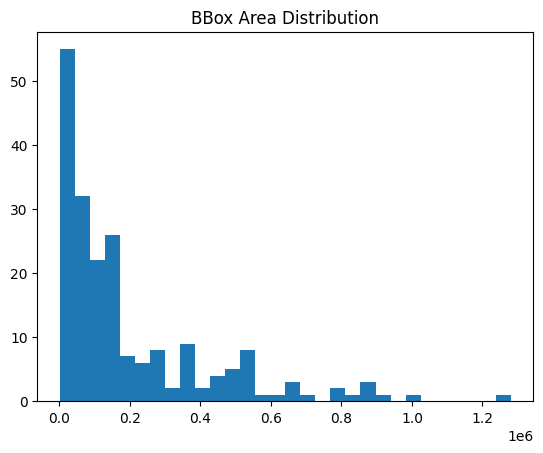

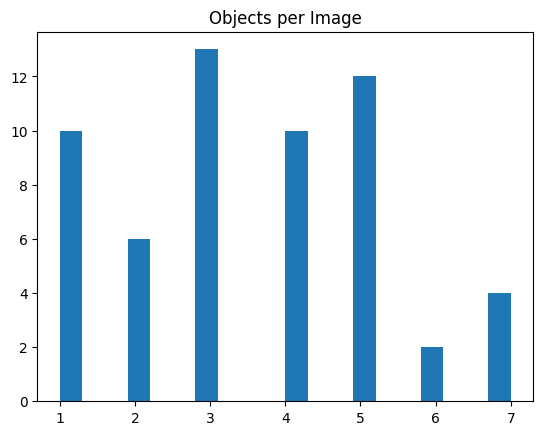


📊 IMBALANCE REPORT:
PartDrawing: 105
Note: 33
Table: 63

Max: 105
Min: 33
Imbalance ratio: 3.18

💾 Saving cleaned dataset...
✅ DONE


In [4]:
def main():
    print("🚀 Loading dataset...")
    data = load_coco_json(ANNOTATION_PATH)
    
    print("\n🧹 Cleaning dataset...")
    data, stats = clean_dataset(data, DATASET_PATH)
    
    print("\n📊 CLEANING STATS:")
    for k, v in stats.items():
        print(f"{k}: {v}")
    
    print(f"Images: {len(data['images'])}")
    print(f"Annotations: {len(data['annotations'])}")
    
    print("\n📊 Running EDA...")
    analyze_and_visualize(data)
    
    print("\n💾 Saving cleaned dataset...")
    save_json(data, OUTPUT_JSON)
    
    print("✅ DONE")


main()